# PHANOTATE-rs ORF score model playground

This notebook trains and benchmarks candidate ORF scoring models for
`phanotate-rs --model`. The goal is to replace (or improve on) the default
PHANOTATE heuristic edge weight with a learned score.

## Cross-validation workflow

Because ORFs from the same genome are highly correlated, we split by
**genome** (not by individual ORF):

1. Load annotated GenBank files.
2. Extract per-ORF features with `phanotate-rs --export-features`.
3. Label each ORF by overlap with the GenBank `CDS` coordinates.
4. For each CV fold:
   - Train a model on the training genomes.
   - Export an ONNX model compatible with `--model`.
   - Run `phanotate-rs --model <onnx>` on each validation genome.
   - Compare predicted genes to GenBank annotations.
5. Pick the best model and re-train on all data.

Any classifier that can be exported to ONNX can be used at runtime; the
notebook uses logistic regression as the default example.


In [1]:
import csv
import json
import re
import shutil
import subprocess
import sys
import tempfile
from pathlib import Path
from tqdm import tqdm

import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve, precision_recall_curve
from sklearn.model_selection import KFold
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# Training helpers (kept self-contained in the notebook)
from typing import List, Tuple, Set

NUM_FEATURES = 34
SUPPORTED_TABLES = {1, 4, 6, 11, 15, 25}

FEATURE_NAMES = [
    "log_length",
    "rbs_bin",
    "log_hold",
    "pstop",
    "sd_rbs_score",
    "start_codon_atg",
    "start_codon_gtg",
    "start_codon_ttg",
    "gc_content",
    "frame_fwd",
    "frame_1",
    "frame_2",
    "frame_3",
    "non_sd_rbs_score",
    "cscore",
    "cai",
    "gc1",
    "gc2",
    "gc3",
    "overlap_upstream_length",
    "overlap_upstream_same_strand",
    "overlap_downstream_length",
    "overlap_downstream_same_strand",
    "stop_sharing_count",
    "gc_skew",
    "truncation_penalty",
    "upstream_pwm_score",
    "rbs_spacer",
    "heuristic_score",
    "best_alt_pwm_score",
    "pwm_ratio",
    "start_rank",
    "num_alt_starts",
    "start_codon_log_freq",
]


def export_linear_to_onnx(
    model: LogisticRegression,
    mean: np.ndarray,
    std: np.ndarray,
    path: Path,
) -> None:
    """Export a standardised logistic-regression model to ONNX."""
    from skl2onnx import convert_sklearn
    from skl2onnx.common.data_types import FloatTensorType
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import StandardScaler

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", solver="lbfgs")),
    ])
    pipe.named_steps["scaler"].mean_ = mean
    pipe.named_steps["scaler"].scale_ = std
    pipe.named_steps["scaler"].var_ = std**2
    pipe.named_steps["scaler"].n_features_in_ = mean.shape[0]
    pipe.named_steps["clf"].coef_ = model.coef_
    pipe.named_steps["clf"].intercept_ = model.intercept_
    pipe.named_steps["clf"].classes_ = model.classes_

    initial_type = [("input", FloatTensorType([None, NUM_FEATURES]))]
    onnx_model = convert_sklearn(
        pipe,
        initial_types=initial_type,
        target_opset=15,
        options={LogisticRegression: {"zipmap": False}},
    )
    path.write_bytes(onnx_model.SerializeToString())


def _extract_origin(text: str) -> str:
    """Return the lower-case nucleotide sequence from a GenBank ORIGIN block."""
    match = re.search(r"ORIGIN\s+(.*?)\n//", text, re.DOTALL)
    if not match:
        raise ValueError("No ORIGIN block found")
    return "".join(re.findall(r"[a-z]+", match.group(1)))


def _parse_location(location: str) -> Tuple[List[Tuple[int, int]], str] | None:
    """Parse a GenBank location string into (segments, strand).

    ``join(...)`` locations are returned as a list of (start, stop) segments,
    so wrap-around CDSs on circular genomes are not collapsed into one giant
    interval.
    """
    loc = location.strip()
    strand = "+"
    if loc.startswith("complement("):
        strand = "-"
        loc = loc[len("complement(") :].rstrip(")")
    if loc.startswith("join("):
        loc = loc[len("join(") :].rstrip(")")

    segments: List[Tuple[int, int]] = []
    for part in loc.split(","):
        part = part.strip()
        m = re.match(r"(\d+)\.\.(\d+)", part)
        if m:
            segments.append((int(m.group(1)), int(m.group(2))))

    if not segments:
        return None
    return segments, strand


def parse_genbank(path: str) -> Tuple[str, List[Tuple[int, int, str, int]]]:
    """Return (sequence, CDS entries) from a GenBank file.

    Each segment of a ``join(...)`` location is emitted as a separate entry,
    so origin-spanning CDSs are represented by their true exons rather than
    one collapsed interval.
    """
    text = Path(path).read_text()
    seq = _extract_origin(text)

    feat_match = re.search(
        r"FEATURES\s+Location/Qualifiers\s+(.*?)(?=^ORIGIN)",
        text,
        re.MULTILINE | re.DOTALL,
    )
    if not feat_match:
        return seq, []

    block = feat_match.group(1)
    entries: List[Tuple[int, int, str, int]] = []
    current: dict | None = None

    for raw_line in block.splitlines():
        if not raw_line.strip():
            continue

        qual_match = re.match(r"^\s{21}/([^=]+)(?:=(.*))?\s*$", raw_line)
        if qual_match and current is not None:
            key = qual_match.group(1).strip()
            value = qual_match.group(2)
            if value is not None:
                value = value.strip().strip('"').strip("'")
            if key == "transl_table":
                try:
                    current["transl_table"] = int(value)
                except (TypeError, ValueError):
                    pass
            continue

        cont_match = re.match(r"^\s{21}(\S.*)$", raw_line)
        if cont_match and current is not None:
            current["location"] += cont_match.group(1)
            continue

        feat_key_match = re.match(r"^\s{5}(\S+)\s+(\S.*)$", raw_line)
        if feat_key_match:
            if current is not None and current["key"] == "CDS":
                parsed = _parse_location(current["location"])
                if parsed is not None:
                    segments, strand = parsed
                    for s, e in segments:
                        entries.append((s, e, strand, current["transl_table"]))
            key = feat_key_match.group(1)
            location = feat_key_match.group(2)
            current = {"key": key, "location": location, "transl_table": 11}

    if current is not None and current["key"] == "CDS":
        parsed = _parse_location(current["location"])
        if parsed is not None:
            segments, strand = parsed
            for s, e in segments:
                entries.append((s, e, strand, current["transl_table"]))

    return seq, entries


def _majority_table(entries: List[Tuple[int, int, str, int]]) -> int | None:
    if not entries:
        return None
    counts: dict[int, int] = {}
    for *_, table in entries:
        counts[table] = counts.get(table, 0) + 1
    return max(counts, key=counts.get)


def _parse_sco_text(text: str) -> Set[Tuple[int, int]]:
    """Parse a PHANOTATE SCO string into a set of (start, stop) coordinates."""
    coords: Set[Tuple[int, int]] = set()
    for line in text.splitlines():
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        parts = line.split("\t")
        if len(parts) < 2:
            continue
        try:
            coords.add((int(parts[0]), int(parts[1])))
        except ValueError:
            continue
    return coords


def _match_coord(
    coord: Tuple[int, int], coord_set: Set[Tuple[int, int]], tolerance: int = 3
) -> bool:
    """Return True if `coord` matches any coordinate in `coord_set` within tolerance."""
    s, e = coord
    for ts, te in coord_set:
        if abs(s - ts) <= tolerance and abs(e - te) <= tolerance:
            return True
    return False


def _normalise_segments(
    start: int, stop: int, genome_len: int
) -> List[Tuple[int, int]]:
    """Split a wrap-around interval (start > stop) into two linear segments."""
    if start <= stop:
        return [(start, stop)]
    return [(start, genome_len), (1, stop)]


def _any_segment_matches(
    start: int,
    stop: int,
    target_set: Set[Tuple[int, int]],
    genome_len: int,
    tolerance: int = 3,
) -> bool:
    """Return True if any segment of ``(start, stop)`` matches a target segment."""
    for seg in _normalise_segments(start, stop, genome_len):
        if _match_coord(seg, target_set, tolerance):
            return True
    return False


def extract_genome_features(
    path: Path,
    binary: str,
    table: int | None = None,
    hard_negatives: bool = False,
) -> dict | None:
    """Extract ORF features and labels from a single annotated GenBank file.

    Returns a dict with keys ``X``, ``y``, ``coords``, ``hard_neg``, ``path``,
    and ``table``.  When ``hard_negatives`` is True, the function runs
    ``phanotate-rs`` in SCO mode and marks predicted ORFs that do not match
    any annotation as hard negatives.
    """
    try:
        seq, entries = parse_genbank(str(path))
    except Exception as exc:
        print(f"Warning: failed to parse {path}: {exc}", file=sys.stderr)
        return None

    if not entries:
        print(f"Warning: no CDS features in {path}, skipping", file=sys.stderr)
        return None

    genome_len = len(seq)

    if table is not None:
        genome_table = table
    else:
        genome_table = _majority_table(entries)
        if genome_table is None:
            print(
                f"Warning: could not determine table for {path}, skipping",
                file=sys.stderr,
            )
            return None
        if genome_table not in SUPPORTED_TABLES:
            print(
                f"Warning: unsupported table {genome_table} in {path}, skipping",
                file=sys.stderr,
            )
            return None

    ann_set: Set[Tuple[int, int]] = set()
    for s, e, strand, _ in entries:
        if abs(e - s) + 1 < 3:
            continue
        ann_set.add((s, e))

    with tempfile.NamedTemporaryFile(mode="w", suffix=".tsv", delete=False) as tmp:
        features_path = tmp.name

    try:
        cmd = [
            binary,
            "-i",
            str(path),
            "-g",
            str(genome_table),
            "--export-features",
            features_path,
        ]
        result = subprocess.run(
            cmd,
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
            text=True,
            check=True,
        )
        if result.returncode != 0:
            print(
                f"Warning: feature export failed for {path}: {result.stderr}",
                file=sys.stderr,
            )
            return None

        rows: List[List[float]] = []
        labels: List[int] = []
        hard_negs: List[int] = []
        coords: List[Tuple[int, int]] = []
        pred_fp_set: Set[Tuple[int, int]] = set()

        if hard_negatives:
            pred_cmd = [
                binary,
                "-i",
                str(path),
                "-g",
                str(genome_table),
                "-f",
                "sco",
            ]
            pred_result = subprocess.run(
                pred_cmd,
                stdout=subprocess.PIPE,
                stderr=subprocess.PIPE,
                text=True,
                check=False,
            )
            if pred_result.returncode == 0:
                pred_set = _parse_sco_text(pred_result.stdout)
                # Split predicted wrap-around ORFs before comparing to annotations
                pred_segments: Set[Tuple[int, int]] = set()
                for s, e in pred_set:
                    pred_segments.update(_normalise_segments(s, e, genome_len))
                pred_fp_set = {
                    c for c in pred_segments if not _match_coord(c, ann_set, 3)
                }
            else:
                print(
                    f"Warning: SCO prediction failed for {path}; "
                    "hard-negative mining skipped.",
                    file=sys.stderr,
                )

        with open(features_path, newline="") as fh:
            reader = csv.DictReader(fh, delimiter="\t")
            for row in reader:
                start = int(row["start"])
                stop = int(row["stop"])
                feat = [float(row[name]) for name in FEATURE_NAMES]
                label = 1 if _any_segment_matches(start, stop, ann_set, genome_len, 3) else 0
                rows.append(feat)
                labels.append(label)
                coords.append((start, stop))
                hard_negs.append(
                    1
                    if label == 0
                    and pred_fp_set
                    and _any_segment_matches(start, stop, pred_fp_set, genome_len, 3)
                    else 0
                )
    finally:
        Path(features_path).unlink(missing_ok=True)

    return {
        "path": path,
        "table": genome_table,
        "X": np.asarray(rows, dtype=float) if rows else np.empty((0, NUM_FEATURES)),
        "y": np.asarray(labels, dtype=int) if labels else np.empty(0, dtype=int),
        "coords": np.asarray(coords, dtype=int) if coords else np.empty((0, 2), dtype=int),
        "hard_neg": np.asarray(hard_negs, dtype=bool)
        if hard_negs
        else np.empty(0, dtype=bool),
    }



def _find_phanotate_binary() -> str:
    """Locate the phanotate-rs binary, preferring release builds."""
    candidates = [
        "../target/release/phanotate-rs",
        "../target/debug/phanotate-rs",
        "phanotate-rs",
    ]
    for cand in candidates:
        found = shutil.which(cand)
        if found:
            return found
    raise RuntimeError(
        "Could not find phanotate-rs binary. Build it with `cargo build --release`."
    )

BINARY = _find_phanotate_binary()
print("Using binary:", BINARY)

# Path to annotated GenBank files
GENBANK_DIR = Path("../tests/golden/annotgenomes")
if not GENBANK_DIR.exists():
    raise FileNotFoundError(f"Directory not found: {GENBANK_DIR}")

gb_paths = sorted(GENBANK_DIR.rglob("*.gb"))
print(f"Found {len(gb_paths)} GenBank files")


Using binary: ../target/release/phanotate-rs
Found 4467 GenBank files


In [2]:
len(FEATURE_NAMES)

34

## 1. Extract features and labels for every genome

We call `phanotate-rs --export-features` for each GenBank file. The first
two columns of the TSV are `start`/`stop`; the remaining columns are the
`OrfFeatures` vector. Labels are derived from GenBank `CDS` features.

In [3]:
def load_genome_features(path: Path, table_override: int | None = None, hard_negatives: bool = False) -> pd.DataFrame:
    """Return a DataFrame of ORF features + labels for one GenBank file.

    When ``hard_negatives`` is True, ORFs that match the default PHANOTATE
    predictions but not the annotation are flagged in the ``hard_neg`` column.
    """
    result = extract_genome_features(
        path,
        binary=BINARY,
        table=table_override,
        hard_negatives=hard_negatives,
    )
    if result is None:
        raise RuntimeError(f"Failed to extract features for {path}")

    coords = result["coords"]
    df = pd.DataFrame(result["X"], columns=FEATURE_NAMES)
    df["start"] = coords[:, 0]
    df["stop"] = coords[:, 1]
    df["genome"] = path.stem
    df["table"] = result["table"]
    df["is_gene"] = result["y"]
    df["hard_neg"] = result["hard_neg"].astype(int)
    return df


### 1.1 sample genomes with diverse gc contents and sizes

In [4]:
def genome_stats(path: Path, table_override: int | None = None):
    '''Return a DataFrame of ORF features + labels for one GenBank file.'''
    seq, entries = parse_genbank(str(path))

    if table_override is not None:
        table = table_override
    else:
        table = _majority_table(entries)
        if table not in SUPPORTED_TABLES:
            raise ValueError(f"Unsupported table {table} in {path}")
    length = len(seq)
    gc_content = (seq.count("g") + seq.count("c")) / length
    return {"path": path, "length": length,"gc": gc_content, "table": table}

In [5]:
records = []
skipped = []
for p in tqdm(gb_paths): # parse all 4000+ genomes
    try:
        records.append(genome_stats(p))
    except Exception as exc:
        skipped.append((p.name, str(exc)))

if skipped:
    print("Skipped files:")
    for name, reason in skipped:
        print(f"  {name}: {reason}")

genome_stats_df = pd.DataFrame(records)
genome_stats_df.head()

100%|██████████| 4467/4467 [00:44<00:00, 100.55it/s]


Skipped files:
  NC_055888.gb: Unsupported table 16 in ../tests/golden/annotgenomes/NC_055888.gb
  NC_055889.gb: Unsupported table 16 in ../tests/golden/annotgenomes/NC_055889.gb
  NC_055890.gb: Unsupported table 16 in ../tests/golden/annotgenomes/NC_055890.gb
  NC_055891.gb: Unsupported table 16 in ../tests/golden/annotgenomes/NC_055891.gb
  NC_055892.gb: Unsupported table 16 in ../tests/golden/annotgenomes/NC_055892.gb
  NC_055893.gb: Unsupported table 16 in ../tests/golden/annotgenomes/NC_055893.gb
  NC_055894.gb: Unsupported table 16 in ../tests/golden/annotgenomes/NC_055894.gb
  NC_055895.gb: Unsupported table 16 in ../tests/golden/annotgenomes/NC_055895.gb
  NC_055896.gb: Unsupported table 16 in ../tests/golden/annotgenomes/NC_055896.gb
  NC_055897.gb: Unsupported table 16 in ../tests/golden/annotgenomes/NC_055897.gb
  NC_055898.gb: Unsupported table 16 in ../tests/golden/annotgenomes/NC_055898.gb
  NC_055899.gb: Unsupported table 16 in ../tests/golden/annotgenomes/NC_055899.gb
 

,path,length,gc,table
0,../tests/golden/annotgenomes/NC_000866.gb,168903,0.352978,11
1,../tests/golden/annotgenomes/NC_000871.gb,37370,0.382740,11
2,../tests/golden/annotgenomes/NC_000872.gb,40739,0.375660,11
3,../tests/golden/annotgenomes/NC_000924.gb,61670,0.493676,11
4,../tests/golden/annotgenomes/NC_000929.gb,36717,0.520549,11


In [6]:
table11_genomes = genome_stats_df.query("table == 11")

In [78]:
# equal-width integer ranges
bin_size = 20000
gc_bin_size = 0.1
table11_genomes["bin"] = (table11_genomes["length"] // bin_size).astype(int) * bin_size
table11_genomes["bin_gc"] = (table11_genomes["gc"] // gc_bin_size).astype(int) * bin_size
sampled_11 = table11_genomes.groupby(["bin", "bin_gc"]).sample(n=1, random_state=42)
# bin labels: 0, 100, 200, ... (floor of each range)

In [80]:
sampled_11

,path,length,gc,table,bin,bin_gc
2421,../tests/golden/annotgenomes/NC_048738.gb,18212,0.279431,11,0,40000
3536,../tests/golden/annotgenomes/NC_055866.gb,18477,0.328787,11,0,60000
2150,../tests/golden/annotgenomes/NC_048032.gb,14123,0.406642,11,0,80000
107,../tests/golden/annotgenomes/NC_005131.gb,7118,0.569542,11,0,100000
3000,../tests/golden/annotgenomes/NC_052938.gb,17510,0.691091,11,0,120000
...,...,...,...,...,...,...
2163,../tests/golden/annotgenomes/NC_048047.gb,322272,0.636791,11,320000,120000
1785,../tests/golden/annotgenomes/NC_042116.gb,354378,0.316462,11,340000,60000
1567,../tests/golden/annotgenomes/NC_041878.gb,378379,0.359190,11,360000,60000
892,../tests/golden/annotgenomes/NC_023719.gb,497513,0.299257,11,480000,40000


In [81]:
table4_genomes = genome_stats_df.query("table == 4")

In [82]:
sampled_4 = table4_genomes.sample(5)

In [83]:
train_genomes = pd.concat([sampled_11, sampled_4 ])["path"].unique()

In [84]:
len(train_genomes)

85

In [85]:
test_genomes = set(genome_stats_df["path"].unique()) - set(train_genomes)

In [86]:
test_genomes = np.array(list(test_genomes))

In [87]:

# random sample genomes
test_genomes = test_genomes[np.random.uniform(0,1, len(test_genomes)) > 0.99]

### 1.2 extract feactures from selected genomes

In [88]:
records = []
skipped = []
for p in tqdm(train_genomes):
    try:
        records.append(load_genome_features(p, hard_negatives=True))
    except Exception as exc:
        skipped.append((p.name, str(exc)))

if skipped:
    print("Skipped files:")
    for name, reason in skipped:
        print(f"  {name}: {reason}")

df = pd.concat(records, ignore_index=True)
print(f"Total ORFs: {len(df)}; genes: {df['is_gene'].sum()}; genomes: {df['genome'].nunique()}")
df.head()


100%|██████████| 85/85 [02:15<00:00,  1.60s/it]


Total ORFs: 420718; genes: 12042; genomes: 85


,log_length,rbs_bin,log_hold,pstop,sd_rbs_score,start_codon_atg,start_codon_gtg,start_codon_ttg,gc_content,frame_fwd,...,pwm_ratio,start_rank,num_alt_starts,start_codon_log_freq,start,stop,genome,table,is_gene,hard_neg
0,4.770685,0.0,-0.517723,0.064065,0.908845,0.0,0.0,0.0,0.350000,1.0,...,1.000000,1.0,1.0,-13.815511,2,121,NC_048738,11,0,1
1,5.036952,16.0,-4.561204,0.098778,2.207339,0.0,0.0,1.0,0.307692,1.0,...,1.000000,1.0,2.0,-1.609438,184,339,NC_048738,11,1,0
2,5.093750,1.0,-4.588402,0.098092,1.428278,0.0,1.0,0.0,0.309091,1.0,...,-0.329336,2.0,2.0,-3.218876,175,339,NC_048738,11,0,1
3,5.337538,3.0,-3.442441,0.100136,1.032586,1.0,0.0,0.0,0.271429,1.0,...,-0.285525,2.0,2.0,-0.274437,347,556,NC_048738,11,1,0
4,5.420535,20.0,-3.535939,0.100326,23.891201,0.0,1.0,0.0,0.280702,1.0,...,1.000000,1.0,2.0,-3.218876,329,556,NC_048738,11,0,1


In [89]:
records = []
skipped = []
for p in tqdm(test_genomes):
    try:
        records.append(load_genome_features(p, hard_negatives=True))
    except Exception as exc:
        skipped.append((p.name, str(exc)))

if skipped:
    print("Skipped files:")
    for name, reason in skipped:
        print(f"  {name}: {reason}")

df_test = pd.concat(records, ignore_index=True)
print(f"Total ORFs: {len(df_test)}; genes: {df_test['is_gene'].sum()}; genomes: {df_test['genome'].nunique()}")
df_test.head()


100%|██████████| 47/47 [00:22<00:00,  2.06it/s]

Total ORFs: 104289; genes: 2519; genomes: 47


,log_length,rbs_bin,log_hold,pstop,sd_rbs_score,start_codon_atg,start_codon_gtg,start_codon_ttg,gc_content,frame_fwd,...,pwm_ratio,start_rank,num_alt_starts,start_codon_log_freq,start,stop,genome,table,is_gene,hard_neg
0,4.574711,0.0,-0.170780,0.041554,0.975128,0.0,0.0,1.0,0.464646,0.0,...,1.0,1.0,1.0,-1.356794,101,3,NC_020479,11,0,0
1,4.634729,0.0,-1.280025,0.041361,0.975128,0.0,1.0,0.0,0.466667,0.0,...,1.0,4.0,4.0,-2.284781,106,2,NC_020479,11,0,0
2,4.744932,0.0,-1.250199,0.036728,0.975128,0.0,1.0,0.0,0.478632,0.0,...,1.0,1.0,4.0,-2.284781,118,2,NC_020479,11,0,0
3,4.820282,0.0,-1.430740,0.038533,0.975128,0.0,1.0,0.0,0.468254,0.0,...,1.0,3.0,4.0,-2.284781,127,2,NC_020479,11,0,0
4,5.111988,0.0,-1.799979,0.035077,0.975128,0.0,0.0,1.0,0.482143,0.0,...,1.0,2.0,4.0,-1.356794,169,2,NC_020479,11,0,0


In [90]:
rows = int(np.ceil(np.exp(np.log(len(FEATURE_NAMES))/2)))
cols = rows

## 2. Quick EDA

Look at feature distributions and how they differ between genes and
non-genes.

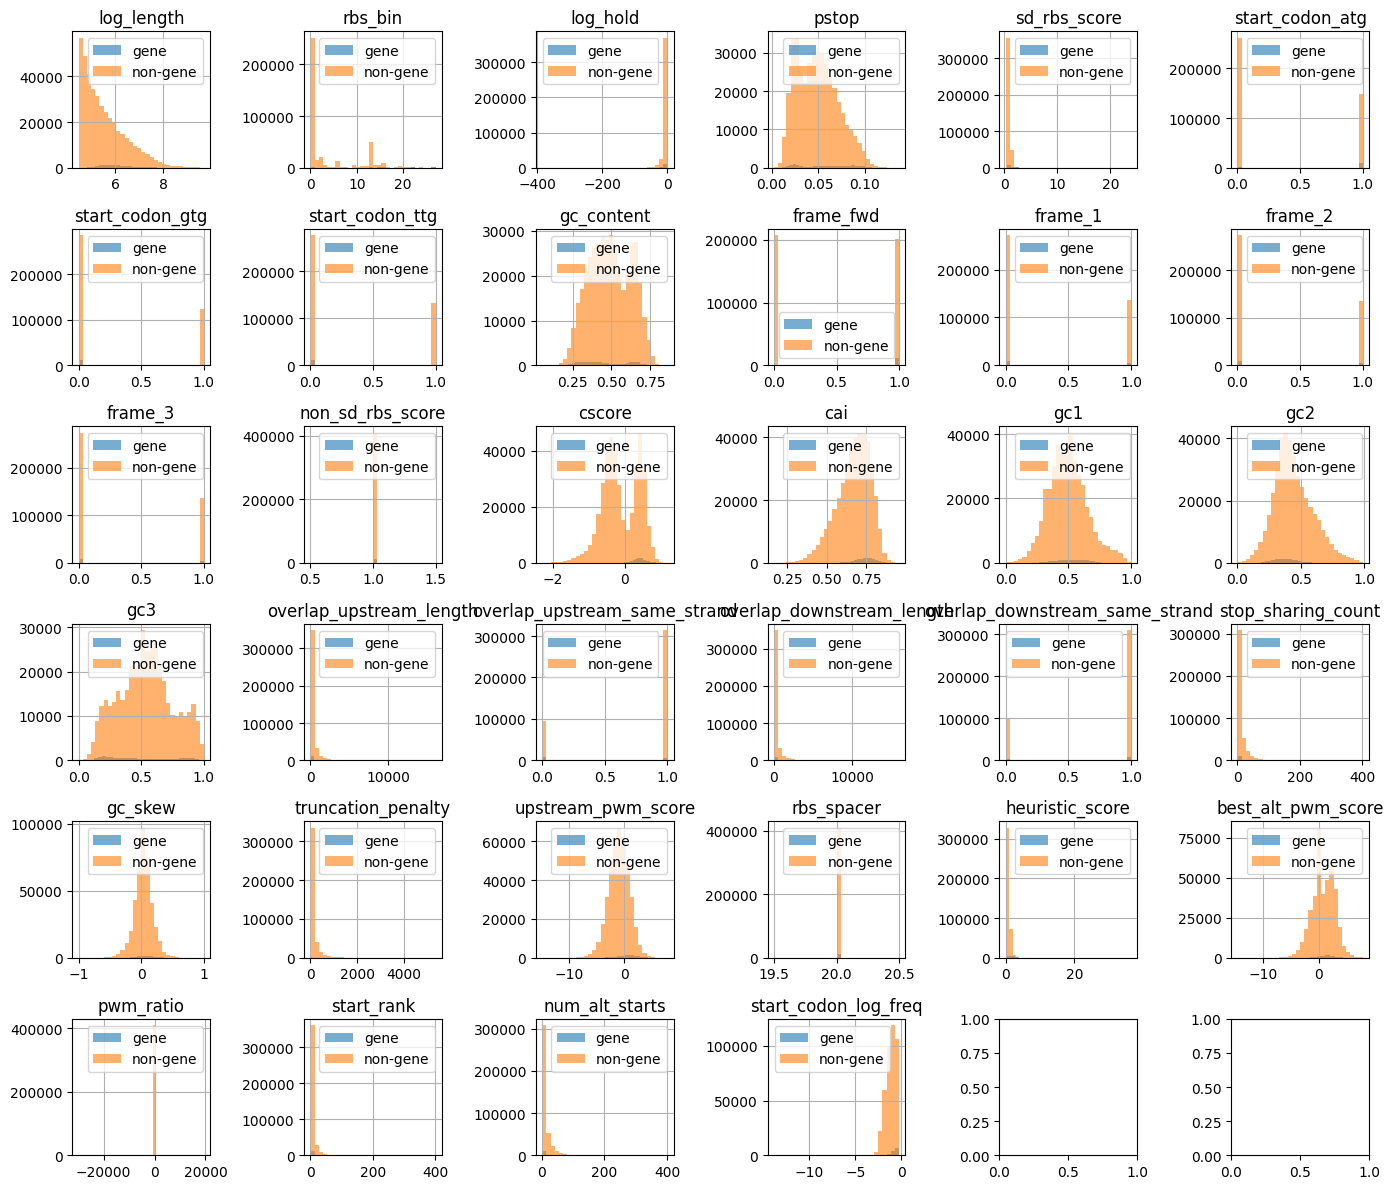

In [91]:
Path("outputs").mkdir(exist_ok=True)

fig, axes = plt.subplots(rows, cols , figsize=(14, 12))
axes = axes.ravel()
for i, col in enumerate(FEATURE_NAMES):
    ax = axes[i]
    df[df["is_gene"] == 1][col].hist(ax=ax, bins=30, alpha=0.6, label="gene")
    df[df["is_gene"] == 0][col].hist(ax=ax, bins=30, alpha=0.6, label="non-gene")
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.savefig("outputs/feature_distributions.png", dpi=150)
plt.show()

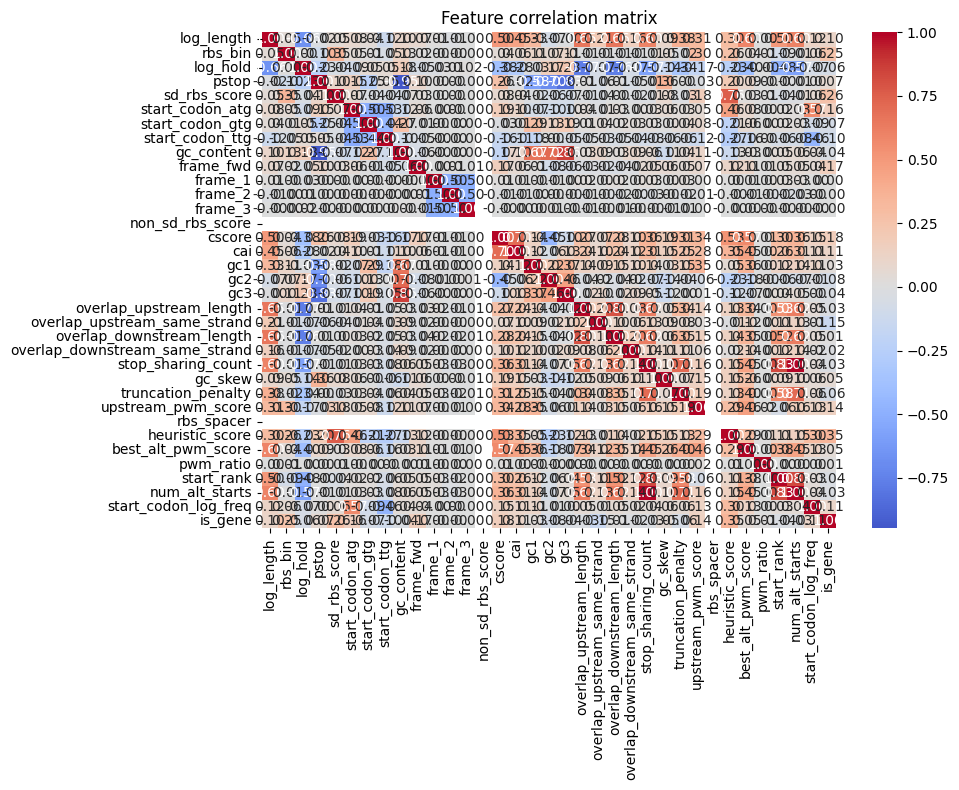

In [92]:
corr = df[FEATURE_NAMES + ["is_gene"]].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature correlation matrix")
plt.tight_layout()
plt.savefig("outputs/feature_correlations.png", dpi=150)
plt.show()

## 3. Genome-stratified cross-validation

We split by `genome`. For each fold we:

- standardise features on the training ORFs,
- fit one or more candidate models,
- export the best model to ONNX,
- run `phanotate-rs --model` on each validation genome,
- compare predicted gene coordinates to the GenBank CDS set.

The helper below converts a fitted linear model into the ONNX format
consumed by `src/onnx_scorer.rs`.


In [93]:
import matplotlib.patches as patches
def genome_cds_set(path: Path) -> set:
    """Return the set of true gene coordinates from a GenBank file.

    Coordinates are normalised to match PHANOTATE's SCO output:
    (start_codon_start, stop_codon_end). For forward genes this is (s, e);
    for reverse genes it is (e, s).
    """
    _, entries = parse_genbank(str(path))
    coords = set()
    for s, e, strand, _ in entries:
        if strand == "+":
            coords.add((s, e))
        else:
            coords.add((e, s))
    return coords


def predict_genes(path: Path, model_path: Path, table: int) -> set:
    """Run phanotate-rs and return the set of predicted (start, stop) genes.

    Coordinates keep PHANOTATE's SCO convention: (start_codon_start,
    stop_codon_end).  For reverse-strand genes this means start > stop.
    """
    cmd = [BINARY, "-i", str(path), "-g", str(table), "-f", "sco"]
    if model_path.exists() and str(model_path) != "/dev/null":
        cmd.extend(["--model", str(model_path)])
    result = subprocess.run(
        cmd,
        check=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True,
    )
    preds = set()
    for line in result.stdout.splitlines():
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        cols = line.split("	")
        if len(cols) >= 2:
            start, stop = int(cols[0]), int(cols[1])
            preds.add((start, stop))
    return preds


def gene_metrics(pred: set, true: set) -> dict:
    """Compute exact-match precision, recall and F1 for predicted genes."""
    tp = len(pred & true)
    fp = len(pred - true)
    fn = len(true - pred)
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) else 0.0
    )
    return {"precision": precision, "recall": recall, "f1": f1, "tp": tp, "fp": fp, "fn": fn}

def _bases(intervals):
    """Return the set of integer positions covered by a collection of closed intervals.

    Intervals may be in PHANOTATE SCO orientation, i.e. (start, stop) with
    start > stop for reverse-strand genes.
    """
    bases = set()
    for s, e in intervals:
        lo, hi = min(s, e), max(s, e)
        bases.update(range(lo, hi + 1))
    return bases


def nucleotide_metrics(pred: set, true: set) -> dict:
    """Compute per-nucleotide precision, recall and F1 for predicted gene intervals."""
    pb = _bases(pred)
    tb = _bases(true)
    tp = len(pb & tb)
    fp = len(pb - tb)
    fn = len(tb - pb)
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) else 0.0
    )
    return {"precision": precision, "recall": recall, "f1": f1, "tp": tp, "fp": fp, "fn": fn}


def coding_density(intervals: set, genome_length: int) -> float:
    """Fraction of the genome covered by the given intervals."""
    if genome_length == 0:
        return 0.0
    return len(_bases(intervals)) / genome_length

def plot_coding_regions(
    intervals: set,
    genome_length: int,
    title: str = "Coding regions",
    ax=None,
    color: str = "steelblue",
    label: str = "coding",
    y_offset: float = 0.0,
    height: float = 0.4,
) -> None:
    """Draw intervals as horizontal bars on a genome map."""
    if ax is None:
        ax = plt.gca()
    for s, e in sorted(intervals):
        lo, hi = min(s, e), max(s, e)
        ax.add_patch(
            patches.Rectangle((lo, y_offset), hi - lo, height, color=color, label=label)
        )
    ax.set_xlim(0, genome_length)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Genome position (bp)")
    ax.set_yticks([])
    ax.set_title(title)


def compare_coding_regions(
    true: set,
    pred: set,
    genome_length: int,
    title: str = "True vs predicted coding regions",
    figsize: Tuple[float, float] = (12, 3),
) -> plt.Figure:
    """Visualise true and predicted coding regions side-by-side."""
    fig, axes = plt.subplots(2, 1, figsize=figsize, sharex=True)
    plot_coding_regions(true, genome_length, title="True annotations", ax=axes[0], color="forestgreen", label="true")
    plot_coding_regions(pred, genome_length, title="Predictions", ax=axes[1], color="steelblue", label="predicted")
    true_density = coding_density(true, genome_length)
    pred_density = coding_density(pred, genome_length)
    axes[0].text(
        0.99, 0.95, f"Coding density: {true_density:.3f}",
        transform=axes[0].transAxes, ha="right", va="top",
    )
    axes[1].text(
        0.99, 0.95, f"Coding density: {pred_density:.3f}",
        transform=axes[1].transAxes, ha="right", va="top",
    )
    plt.tight_layout()
    return fig


In [94]:
def sample_for_xgboost(
    X: np.ndarray,
    y: np.ndarray,
    hard_neg: np.ndarray | None = None,
    neg_per_pos: int = 10,
    seed: int = 42,
) -> tuple[np.ndarray, np.ndarray]:
    """Subsample negatives for XGBoost, prioritising hard negatives.

    Mirrors ``scripts/train_orf_score_model.py``: keep all positives and up to
    ``neg_per_pos`` negatives per positive, preferring hard negatives (ORFs
    PHANOTATE predicted as genes but which do not match the annotation).
    """
    pos_idx = np.where(y == 1)[0]
    neg_idx = np.where(y == 0)[0]
    n_pos = len(pos_idx)
    n_neg_target = min(len(neg_idx), n_pos * neg_per_pos)
    rng = np.random.default_rng(seed)

    if hard_neg is not None and hard_neg.any():
        hard_neg_idx = np.where((y == 0) & hard_neg)[0]
        other_neg_idx = np.where((y == 0) & ~hard_neg)[0]
        n_other = max(0, n_neg_target - len(hard_neg_idx))
        sel_other = rng.choice(
            other_neg_idx,
            size=min(len(other_neg_idx), n_other),
            replace=False,
        )
        sel_neg = np.concatenate([hard_neg_idx, sel_other])
    else:
        sel_neg = rng.choice(neg_idx, size=n_neg_target, replace=False)
    sel = np.concatenate([pos_idx, sel_neg])
    return X[sel], y[sel]


In [95]:
genome_ids = df["genome"].unique()
n_folds = min(3, len(genome_ids))
kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)

fold_results = []
fold_idx = 1
for train_idx, val_idx in kf.split(genome_ids):
    train_genomes = genome_ids[train_idx]
    val_genomes = genome_ids[val_idx]

    train_df = df[df["genome"].isin(train_genomes)]
    val_df = df[df["genome"].isin(val_genomes)]

    X_train = train_df[FEATURE_NAMES].values
    y_train = train_df["is_gene"].values
    X_val = val_df[FEATURE_NAMES].values
    y_val = val_df["is_gene"].values

    mean = X_train.mean(axis=0)
    std = X_train.std(axis=0)
    std[std == 0.0] = 1.0

    # Candidate 1: logistic regression (exportable)
    lr = LogisticRegression(max_iter=1000, class_weight="balanced", solver="lbfgs")
    lr.fit((X_train - mean) / std, y_train)
    val_prob_lr = lr.predict_proba((X_val - mean) / std)[:, 1]

    # Candidate 2: XGBoost (exportable via ONNX), trained on hard negatives
    hard_train = train_df["hard_neg"].values if "hard_neg" in train_df.columns else None
    X_train_xgb, y_train_xgb = sample_for_xgboost(X_train, y_train, hard_train, neg_per_pos=10, seed=42)
    xgb_fold = XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=(len(y_train_xgb) - y_train_xgb.sum()) / y_train_xgb.sum(),
        n_jobs=-1,
        random_state=42,
        eval_metric="logloss",
    )
    xgb_fold.fit(X_train_xgb, y_train_xgb)
    val_prob_xgb = xgb_fold.predict_proba(X_val)[:, 1]

    # ORF-level classification metrics
    orf_metrics = {
        "fold": fold_idx,
        "n_train_genomes": len(train_genomes),
        "n_val_genomes": len(val_genomes),
        "lr_auc": roc_auc_score(y_val, val_prob_lr),
        "xgb_auc": roc_auc_score(y_val, val_prob_xgb),
    }

    # Export the logistic-regression model and run the full PHANOTATE pipeline
    model_path = Path(f"outputs/model_fold{fold_idx}.onnx")
    export_linear_to_onnx(lr, mean, std, model_path)

    pipeline_metrics = []
    for p in gb_paths:
        if p.stem not in val_genomes:
            continue
        table = int(df[df["genome"] == p.stem]["table"].iloc[0])
        pred = predict_genes(p, model_path, table)
        true = genome_cds_set(p)
        m = gene_metrics(pred, true)
        m["genome"] = p.stem
        pipeline_metrics.append(m)

    if pipeline_metrics:
        pm = pd.DataFrame(pipeline_metrics)
        orf_metrics["pipeline_precision"] = pm["precision"].mean()
        orf_metrics["pipeline_recall"] = pm["recall"].mean()
        orf_metrics["pipeline_f1"] = pm["f1"].mean()

    fold_results.append(orf_metrics)
    print(f"Fold {fold_idx}: {orf_metrics}")
    fold_idx += 1

pd.DataFrame(fold_results)


Fold 1: {'fold': 1, 'n_train_genomes': 56, 'n_val_genomes': 29, 'lr_auc': 0.9875017187260139, 'xgb_auc': 0.9938712140546802, 'pipeline_precision': np.float64(0.6500632254303761), 'pipeline_recall': np.float64(0.7377748441299409), 'pipeline_f1': np.float64(0.6889706824536771)}
Fold 2: {'fold': 2, 'n_train_genomes': 57, 'n_val_genomes': 28, 'lr_auc': 0.9864576461758667, 'xgb_auc': 0.9916566611210342, 'pipeline_precision': np.float64(0.5988411835662409), 'pipeline_recall': np.float64(0.6741797572600999), 'pipeline_f1': np.float64(0.6323540187229028)}
Fold 3: {'fold': 3, 'n_train_genomes': 57, 'n_val_genomes': 28, 'lr_auc': 0.9835709393298847, 'xgb_auc': 0.9908175864056257, 'pipeline_precision': np.float64(0.5937678394834763), 'pipeline_recall': np.float64(0.6783898559000904), 'pipeline_f1': np.float64(0.6311958441156228)}


,fold,n_train_genomes,n_val_genomes,lr_auc,xgb_auc,pipeline_precision,pipeline_recall,pipeline_f1
0,1,56,29,0.987502,0.993871,0.650063,0.737775,0.688971
1,2,57,28,0.986458,0.991657,0.598841,0.674180,0.632354
2,3,57,28,0.983571,0.990818,0.593768,0.678390,0.631196


## 4. Compare candidate models

Plot ORF-level ROC and PR curves on held-out genomes. The exportable model
is logistic regression; XGBoost is shown for comparison.

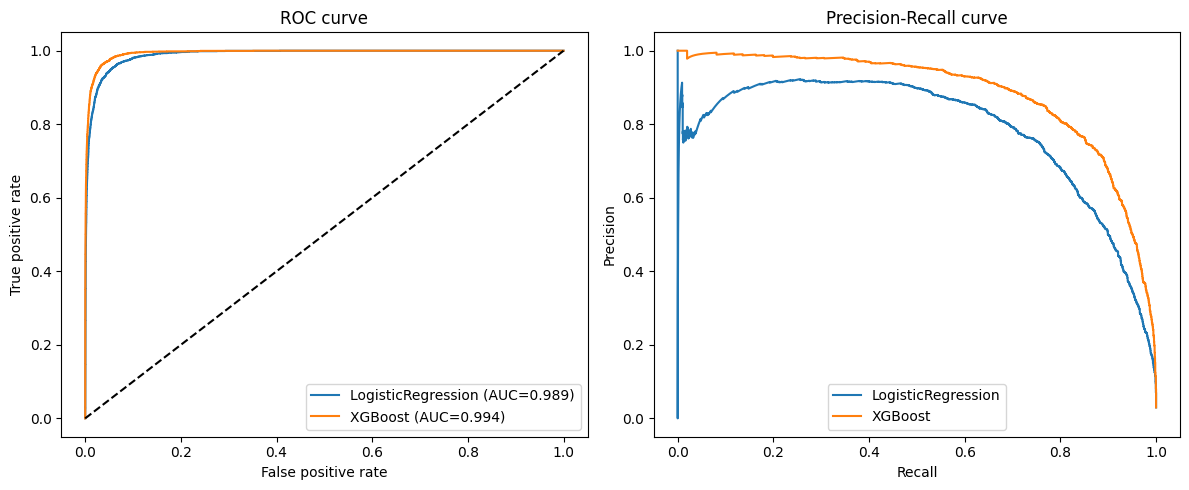

In [96]:
# Simple held-out split for model comparison plots
np.random.seed(42)
val_genomes_plot = np.random.choice(genome_ids, size=max(1, len(genome_ids) // 5), replace=False)
train_genomes_plot = [g for g in genome_ids if g not in val_genomes_plot]

train_df_p = df[df["genome"].isin(train_genomes_plot)]
val_df_p = df[df["genome"].isin(val_genomes_plot)]
X_train_p = train_df_p[FEATURE_NAMES].values
y_train_p = train_df_p["is_gene"].values
X_val_p = val_df_p[FEATURE_NAMES].values
y_val_p = val_df_p["is_gene"].values

mean_p = X_train_p.mean(axis=0)
std_p = X_train_p.std(axis=0)
std_p[std_p == 0.0] = 1.0

models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, class_weight="balanced", solver="lbfgs"),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=(len(y_train_p) - y_train_p.sum()) / y_train_p.sum(),
        n_jobs=-1,
        random_state=42,
        eval_metric="logloss",
    ),
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
hard_train_p = train_df_p["hard_neg"].values if "hard_neg" in train_df_p.columns else None
X_train_p_xgb, y_train_p_xgb = sample_for_xgboost(X_train_p, y_train_p, hard_train_p, seed=42)

for name, m in models.items():
    if name == "LogisticRegression":
        m.fit((X_train_p - mean_p) / std_p, y_train_p)
        prob = m.predict_proba((X_val_p - mean_p) / std_p)[:, 1]
    else:
        m.fit(X_train_p_xgb, y_train_p_xgb)
        prob = m.predict_proba(X_val_p)[:, 1]
    fpr, tpr, _ = roc_curve(y_val_p, prob)
    prec, rec, _ = precision_recall_curve(y_val_p, prob)
    ax1.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_val_p, prob):.3f})")
    ax2.plot(rec, prec, label=f"{name}")

ax1.plot([0, 1], [0, 1], "k--")
ax1.set_xlabel("False positive rate")
ax1.set_ylabel("True positive rate")
ax1.set_title("ROC curve")
ax1.legend()

ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.set_title("Precision-Recall curve")
ax2.legend()

plt.tight_layout()
plt.savefig("outputs/model_comparison.png", dpi=150)
plt.show()


### 4.1 picking up the best threshold

In [97]:
for name, m in models.items():
    if name == "LogisticRegression":
        m.fit((X_train_p - mean_p) / std_p, y_train_p)
        prob = m.predict_proba((X_val_p - mean_p) / std_p)[:, 1]
    else:
        m.fit(X_train_p, y_train_p)
        prob = m.predict_proba(X_val_p)[:, 1]
    print(name)
    precision, recall, thresholds = precision_recall_curve(y_val_p, prob)
    precision = precision[:-1]
    recall    = recall[:-1]
    target_recall = 0.95
    valid = recall >= target_recall
    best_idx = np.argmax(precision[valid])
    best_threshold = thresholds[valid][best_idx]
    print(f"Recall 0.95 at threshold={best_threshold}")

    f1 = 2 * precision * recall / (precision + recall + 1e-12)
    best_idx = np.argmax(f1)
    best_threshold = thresholds[best_idx]
    print(f"Best F1={f1[best_idx]:.3f} at threshold={best_threshold:.7f}")

    fpr, tpr, thresholds_roc = roc_curve(y_val_p, prob)
    j = tpr - fpr
    best_idx = np.argmax(j)
    best_threshold = thresholds_roc[best_idx]
    print(f"Youden's J={j[best_idx]:.3f} at threshold={best_threshold:.3f}")



LogisticRegression
Recall 0.95 at threshold=0.6373944358556105
Best F1=0.753 at threshold=0.9460945
Youden's J=0.897 at threshold=0.622
XGBoost
Recall 0.95 at threshold=0.7122235894203186
Best F1=0.808 at threshold=0.9621518
Youden's J=0.931 at threshold=0.578


## 5. Train final model and export

Retrain the chosen model on all genomes and export it to ONNX.
Both logistic-regression and non-linear classifiers (e.g. XGBoost) can
be exported to ONNX and used directly with `phanotate-rs --model`.


In [98]:
X_all = df[FEATURE_NAMES].values
y_all = df["is_gene"].values
X_test  = df_test[FEATURE_NAMES].values
y_test = df_test["is_gene"].values

mean_all = X_all.mean(axis=0)
std_all = X_all.std(axis=0)
std_all[std_all == 0.0] = 1.0

final_model = LogisticRegression(max_iter=1000, class_weight="balanced", solver="lbfgs")
final_model.fit((X_all - mean_all) / std_all, y_all)

onnx_path = Path("outputs/model_final.onnx")
export_linear_to_onnx(final_model, mean_all, std_all, onnx_path)
print(f"Exported ONNX model to {onnx_path}")

# Show feature importance (coefficients)
coef_df = pd.DataFrame({"feature": FEATURE_NAMES, "coeff": final_model.coef_.ravel()})
coef_df = coef_df.sort_values("coeff", key=abs, ascending=False)
print(coef_df)

Exported ONNX model to outputs/model_final.onnx
                           feature     coeff
25              truncation_penalty -5.546351
9                        frame_fwd  4.025179
14                          cscore  2.930765
7                  start_codon_ttg -1.097776
0                       log_length  0.886247
1                          rbs_bin  0.850112
6                  start_codon_gtg -0.807866
28                 heuristic_score -0.644478
4                     sd_rbs_score  0.534138
20    overlap_upstream_same_strand -0.486614
32                  num_alt_starts -0.452642
23              stop_sharing_count -0.452642
29              best_alt_pwm_score -0.452428
19         overlap_upstream_length -0.347017
3                            pstop  0.343305
18                             gc3  0.214902
31                      start_rank  0.212987
8                       gc_content  0.157716
15                             cai -0.155524
2                         log_hold  0.118796
26     

## 5b. Validate the ONNX model end-to-end


In [99]:
# Quick sanity check: compare ONNX predictions to annotations for one genome
example_genome =  gb_paths[0]
seq, records = parse_genbank(gb_paths[0])
example_table = _majority_table(records)
true_set = genome_cds_set(example_genome)
model_pred_onnx = predict_genes(example_genome, onnx_path, example_table)
print("ONNX model:", gene_metrics(model_pred_onnx, true_set))


ONNX model: {'precision': 0.7921146953405018, 'recall': 0.7836879432624113, 'f1': 0.787878787878788, 'tp': 221, 'fp': 58, 'fn': 61}


## 6. Validate the final model on a held-out genome

Pick a genome not seen during final training (or the same CV validation set)
and compare `--model` predictions to the GenBank annotations.

In [100]:
# Example: validate on the first validation-genome from the last CV fold
example_genome =  gb_paths[0]
seq, records = parse_genbank(gb_paths[0])
example_table = _majority_table(records)

default_pred = predict_genes(example_genome, Path("/dev/null"), example_table)
model_pred = predict_genes(example_genome, onnx_path, example_table)
true_set = genome_cds_set(example_genome)

print("Default PHANOTATE:", gene_metrics(default_pred, true_set))
print("Learned model:", gene_metrics(model_pred, true_set))


Default PHANOTATE: {'precision': 0.8215488215488216, 'recall': 0.8652482269503546, 'f1': 0.842832469775475, 'tp': 244, 'fp': 53, 'fn': 38}
Learned model: {'precision': 0.7921146953405018, 'recall': 0.7836879432624113, 'f1': 0.787878787878788, 'tp': 221, 'fp': 58, 'fn': 61}


## 7. Train an XGBoost model and compare

XGBoost can capture non-linear relationships between features (e.g. interactions between RBS signals, start codon and dicodon score). We train one on the same data, export it to ONNX, and compare the end-to-end gene predictions against the logistic-regression and default PHANOTATE models.


In [101]:
def export_xgboost_to_onnx(model, path: Path, n_features: int = NUM_FEATURES) -> None:
    """Export an XGBoost classifier to ONNX."""
    from onnxmltools.convert.common.data_types import FloatTensorType
    import onnxmltools

    onnx_model = onnxmltools.convert_xgboost(
        model, initial_types=[("input", FloatTensorType([None, n_features]))]
    )
    path.write_bytes(onnx_model.SerializeToString())


In [102]:
from xgboost import XGBClassifier

# Train an XGBoost classifier on all genomes, prioritising hard negatives
hard_all = df["hard_neg"].values if "hard_neg" in df.columns else None
X_all_xgb, y_all_xgb = sample_for_xgboost(X_all, y_all, hard_all, neg_per_pos=10, seed=42)

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(len(y_all_xgb) - y_all_xgb.sum()) / y_all_xgb.sum(),
    n_jobs=-1,
    random_state=42,
    eval_metric="logloss",
)
xgb.fit(X_all_xgb, y_all_xgb)

xgb_path = Path("outputs/model_xgb.onnx")
export_xgboost_to_onnx(xgb, xgb_path)
print(f"Exported XGBoost model to {xgb_path}")

# Feature importances
importance_df = pd.DataFrame({"feature": FEATURE_NAMES, "importance": xgb.feature_importances_})
importance_df = importance_df.sort_values("importance", ascending=False)
print(importance_df)


Exported XGBoost model to outputs/model_xgb.onnx
                           feature  importance
9                        frame_fwd    0.553867
28                 heuristic_score    0.121056
25              truncation_penalty    0.051579
20    overlap_upstream_same_strand    0.043820
14                          cscore    0.042992
1                          rbs_bin    0.039447
8                       gc_content    0.024333
5                  start_codon_atg    0.016302
3                            pstop    0.015231
31                      start_rank    0.010946
23              stop_sharing_count    0.010094
0                       log_length    0.009980
19         overlap_upstream_length    0.008233
18                             gc3    0.006934
29              best_alt_pwm_score    0.005815
32                  num_alt_starts    0.005352
2                         log_hold    0.004757
7                  start_codon_ttg    0.004349
33            start_codon_log_freq    0.003756
24         

In [103]:
prob = xgb.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, prob)
precision = precision[:-1]
recall    = recall[:-1]
target_recall = 0.95
valid = recall >= target_recall
best_idx = np.argmax(precision[valid])
best_threshold = thresholds[valid][best_idx]
print(f"Recall 0.90 at threshold={best_threshold}")

f1 = 2 * precision * recall / (precision + recall + 1e-12)
best_idx = np.argmax(f1)
best_threshold = thresholds[best_idx]
print(f"Best F1={f1[best_idx]:.3f} at threshold={best_threshold:.7f}")

Recall 0.90 at threshold=0.7263922691345215
Best F1=0.812 at threshold=0.9600148


In [104]:
f1

array([0.04716875, 0.04716919, 0.04716963, ..., 0.00237906, 0.00158667,
       0.00079365], shape=(102817,))

In [105]:
# Compare default, logistic-regression and XGBoost predictions on one genome
example_genome =  gb_paths[0]
seq, records = parse_genbank(gb_paths[0])
example_table = _majority_table(records)
true_set = genome_cds_set(example_genome)

default_pred = predict_genes(example_genome, Path("/dev/null"), example_table)
lr_pred = predict_genes(example_genome, onnx_path, example_table)
xgb_pred = predict_genes(example_genome, xgb_path, example_table)

print("Default PHANOTATE:", gene_metrics(default_pred, true_set))
print("Logistic regression:", gene_metrics(lr_pred, true_set))
print("XGBoost:          ", gene_metrics(xgb_pred, true_set))


Default PHANOTATE: {'precision': 0.8215488215488216, 'recall': 0.8652482269503546, 'f1': 0.842832469775475, 'tp': 244, 'fp': 53, 'fn': 38}
Logistic regression: {'precision': 0.7921146953405018, 'recall': 0.7836879432624113, 'f1': 0.787878787878788, 'tp': 221, 'fp': 58, 'fn': 61}
XGBoost:           {'precision': 0.7509293680297398, 'recall': 0.7163120567375887, 'f1': 0.7332123411978221, 'tp': 202, 'fp': 67, 'fn': 80}


## 8. Benchmark against PHANOTATE-rs 0.1.2 and prodigal-gv

Add two additional baselines:

- **PHANOTATE-rs 0.1.2**: the previous Rust release, built from the `v0.1.2` git tag and placed at `tools/phanotate-rs-0.1.2`.
- **prodigal-gv**: the viral-aware prodigal fork, run through the `pyrodigal-gv` Python bindings.


In [106]:
from pathlib import Path
import subprocess
import pyrodigal_gv

PHANOTATE_RS_012 = Path("phanotate-rs").resolve()

def predict_genes_phanotate_rs_012(path: Path, table: int) -> set:
    """Run PHANOTATE-rs v0.1.2 and return predicted (start, stop) genes."""
    if not PHANOTATE_RS_012.exists():
        raise FileNotFoundError(
            f"PHANOTATE-rs 0.1.2 binary not found at {PHANOTATE_RS_012}. "
            "Build it from the v0.1.2 tag: git worktree add /tmp/phanotate-rs-0.1.2-src v0.1.2 && cargo build --release"
        )
    cmd = [str(PHANOTATE_RS_012), "-i", str(path), "-g", str(table), "-f", "sco"]
    result = subprocess.run(
        cmd,
        check=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True,
    )
    preds = set()
    for line in result.stdout.splitlines():
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        cols = line.split("\t")
        if len(cols) >= 2:
            start, stop = int(cols[0]), int(cols[1])
            # Normalise to (low, high) regardless of strand.
            preds.add((min(start, stop), max(start, stop)))
    return preds

def predict_genes_prodigal_gv(path: Path, table: int | None = None) -> set:
    """Run prodigal-gv via pyrodigal-gv and return predicted (start, stop) genes.

    Coordinates are normalised to PHANOTATE's SCO convention:
    (start_codon_start, stop_codon_end).  Forward genes are (begin, end);
    reverse genes are (end, begin).
    """
    seq, _ = parse_genbank(str(path))
    finder = pyrodigal_gv.ViralGeneFinder(meta=True)
    genes = finder.find_genes(seq)
    preds = set()
    for g in genes:
        if g.strand == 1:
            preds.add((g.begin, g.end))
        else:
            preds.add((g.end, g.begin))
    return preds


In [107]:
# Original Python PHANOTATE (requires the sibling ../PHANOTATE repo and a Python env with its deps)
PHANOTATE_PY = Path.cwd().parent.parent / "PHANOTATE" / "phanotate.py"
PHANOTATE_PY_PYTHON = Path("/Users/javis/miniconda3/envs/phanotate_rs/bin/python")

def predict_genes_phanotate_py(path: Path, table: int | None = None) -> set:
    """Run the original Python PHANOTATE and return predicted (start, stop) genes."""
    if not PHANOTATE_PY.exists():
        raise FileNotFoundError(
            f"Original PHANOTATE not found at {PHANOTATE_PY}. "
            "Clone it next to this repo: git clone https://github.com/deprekate/PHANOTATE.git ../PHANOTATE"
        )
    seq, _ = parse_genbank(str(path))
    with tempfile.NamedTemporaryFile(mode="w", suffix=".fna", delete=False) as tmp:
        tmp.write(f">{path.stem}\n{seq}\n")
        fasta = tmp.name
    try:
        result = subprocess.run(
            [str(PHANOTATE_PY_PYTHON), str(PHANOTATE_PY), "-f", "tabular", fasta],
            check=True,
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
            text=True,
        )
    finally:
        Path(fasta).unlink(missing_ok=True)

    preds = set()
    for line in result.stdout.splitlines():
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        cols = line.split("\t")
        if len(cols) >= 3:
            start, stop = int(cols[0]), int(cols[1])
            # Original PHANOTATE outputs forward (start<stop) and reverse (start>stop).
            # Normalise to the same SCO convention used by phanotate-rs: (low, high).
            preds.add((min(start, stop), max(start, stop)))
    return preds


In [128]:
# Conda-installed PHANOTATE-rs binary (may differ from the local dev build)
PHANOTATE_RS_CONDA = Path("../target/release/phanotate-rs")

def predict_genes_phanotate_rs_conda(
    model_path: Path,
    path: Path,
    table: int,
    model_threshold: float,
    overlap_lambda: float,
    overlap_threshold: float = 1,
    overlap_penalty_weight: float = 0.3,
    model_scale: float = 1.0,
) -> set:
    """Run the conda-installed phanotate-rs binary and return predicted gene coordinates.

    Coordinates keep PHANOTATE's SCO convention: (start_codon_start,
    stop_codon_end), so reverse-strand genes have start > stop.
    """
    if not PHANOTATE_RS_CONDA.exists():
        raise FileNotFoundError(f"Conda phanotate-rs binary not found at {PHANOTATE_RS_CONDA}")
    cmd = [
        str(PHANOTATE_RS_CONDA),
        "-i", str(path),
        "-g", str(table),
        "-f", "sco",
        "--model-threshold", str(model_threshold),
        "--model", str(model_path),
       "--find-overlaps",
        "--overlap-lambda", str(overlap_lambda),
        "--overlap-threshold", str(overlap_threshold),
        "--overlap-penalty-weight", str(overlap_penalty_weight),
        "--model-scale", str(model_scale),
    ]
    result = subprocess.run(
        cmd,
        check=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True,
    )
    preds = set()
    for line in result.stdout.splitlines():
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        cols = line.split("\t")
        if len(cols) >= 2:
            start, stop = int(cols[0]), int(cols[1])
            preds.add((start, stop))
    return preds


In [109]:
! ls ../models

default.onnx


In [110]:
# Compare all predictors on the example genome
example_genome = gb_paths[400]
seq, records = parse_genbank(gb_paths[400])
example_table = _majority_table(records)
true_set = genome_cds_set(example_genome)
example_len = len(seq)

default_pred = predict_genes(example_genome, Path("../models/default.onnx"), example_table)
lr_pred = predict_genes(example_genome, onnx_path, example_table)
xgb_pred = predict_genes(example_genome, xgb_path, example_table)
# py_pred = predict_genes_phanotate_py(example_genome, example_table)
# old_pred = predict_genes_phanotate_rs_012(example_genome, example_table)
conda_pred = predict_genes_phanotate_rs_conda(
    xgb_path,
    example_genome,
    example_table,
    model_threshold=0.5,
    overlap_lambda=0,
    overlap_threshold=0.7,
    overlap_penalty_weight=0.3,
    model_scale=0.5,
)
pgv_pred = predict_genes_prodigal_gv(example_genome, example_table)

print(f"Genome: {example_genome.stem} ({example_len} bp)")
print(f"{'Predictor':<28} {'G_Prec':>7} {'G_Rec':>7} {'G_F1':>7} {'TP':>5} {'FP':>5} {'FN':>5} {'N_Prec':>7} {'N_Rec':>7} {'N_F1':>7} {'PredDens':>9} {'TrueDens':>9}")
print("-" * 95)
true_density = coding_density(true_set, example_len)
predictors = [
    ("Default PHANOTATE-rs 0.1.3", default_pred),
    ("Logistic regression", lr_pred),
    ("XGBoost", xgb_pred),
    ("prodigal-gv", pgv_pred),
    ("PHANOTATE-rs (conda)", conda_pred),
]
for label, preds in predictors:
    gm = gene_metrics(preds, true_set)
    nm = nucleotide_metrics(preds, true_set)
    pred_density = coding_density(preds, example_len)
    print(
        f"{label:<28} "
        f"{gm['precision']:>7.3f} {gm['recall']:>7.3f} {gm['f1']:>7.3f} "
        f"{gm['tp']:>5} {gm['fp']:>5} {gm['fn']:>5} "
        f"{nm['precision']:>7.3f} {nm['recall']:>7.3f} {nm['f1']:>7.3f} "
        f"{pred_density:>9.4f} {true_density:>9.4f}"
    )


Genome: NC_015253 (127065 bp)
Predictor                     G_Prec   G_Rec    G_F1    TP    FP    FN  N_Prec   N_Rec    N_F1  PredDens  TrueDens
-----------------------------------------------------------------------------------------------
Default PHANOTATE-rs 0.1.3     0.861   0.865   0.863   173    28    27   0.983   0.990   0.986    0.9087    0.9030
Logistic regression            0.817   0.825   0.821   165    37    35   0.982   0.983   0.982    0.9039    0.9030
XGBoost                        0.827   0.835   0.831   167    35    33   0.983   0.984   0.984    0.9048    0.9030
prodigal-gv                    0.933   0.760   0.837   152    11    48   0.999   0.948   0.973    0.8575    0.9030
PHANOTATE-rs (conda)           0.842   0.850   0.846   170    32    30   0.983   0.989   0.986    0.9088    0.9030


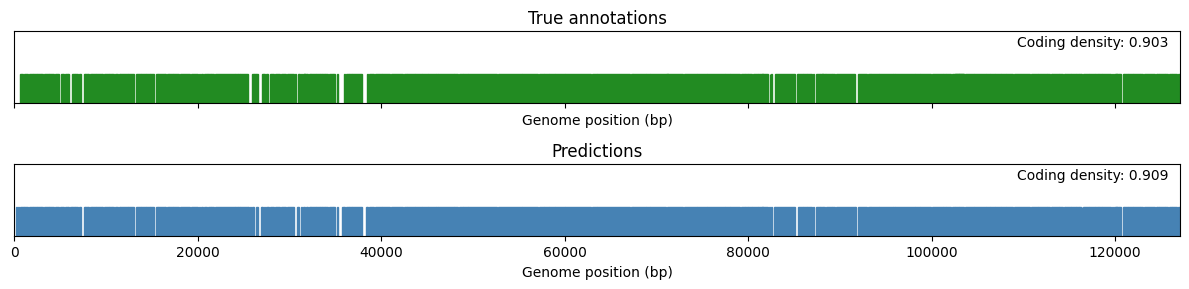

In [111]:
fig = compare_coding_regions(true_set, conda_pred, example_len) 

## 9. Small-genome benchmark: NC_001365 (SpV1, table 4 with auto-detection)

Compare predictors on the small `tests/golden/NC_001365.fa` genome, where the correct translation table is 4. PHANOTATE-rs is run with `--detect-table`; prodigal-gv is run in meta mode (its single-mode trainer refuses sequences < 20 kb).


In [114]:
table4_genomes

,path,length,gc,table
6,../tests/golden/annotgenomes/NC_001270.gb,6825,0.226520,4
13,../tests/golden/annotgenomes/NC_001365.gb,8273,0.228938,4
44,../tests/golden/annotgenomes/NC_002515.gb,11660,0.267925,4
63,../tests/golden/annotgenomes/NC_003793.gb,7768,0.231591,4
267,../tests/golden/annotgenomes/NC_009987.gb,7870,0.222109,4
576,../tests/golden/annotgenomes/NC_019523.gb,18919,0.278027,4
4354,../tests/golden/annotgenomes/NC_073761.gb,7878,0.230135,4


In [115]:
sampled_4

,path,length,gc,table
63,../tests/golden/annotgenomes/NC_003793.gb,7768,0.231591,4
13,../tests/golden/annotgenomes/NC_001365.gb,8273,0.228938,4
267,../tests/golden/annotgenomes/NC_009987.gb,7870,0.222109,4
576,../tests/golden/annotgenomes/NC_019523.gb,18919,0.278027,4
4354,../tests/golden/annotgenomes/NC_073761.gb,7878,0.230135,4


In [144]:
128+64+32

224

In [142]:
NC_001365_FASTA = Path("../tests/golden/annotgenomes_fa/NC_054814.fa").resolve()
NC_001365_GB = Path("../tests/golden/annotgenomes_gb/NC_054814.gb").resolve()

nc_true = genome_cds_set(NC_001365_GB)
nc_seq, _ = parse_genbank(str(NC_001365_GB))
nc_len = len(nc_seq)
print(f"Genome length: {nc_len} bp")
print(f"True CDS: {len(nc_true)}")

nc_default_detect = predict_genes(NC_001365_FASTA, Path("../models/default.onnx"), table=11)  # same as --detect-table result
nc_lr = predict_genes(NC_001365_FASTA, onnx_path, table=11)
nc_xgb = predict_genes_phanotate_rs_conda(
    xgb_path,
    NC_001365_FASTA,
    table=4,
    model_threshold=0.5,
    overlap_lambda=0,
    overlap_threshold=0.7,
    overlap_penalty_weight=0.3,
    model_scale=0.5,
)

# prodigal-gv in meta mode (table-4 training requires >= 20 kb)
gf_nc = pyrodigal_gv.ViralGeneFinder(meta=True)
nc_pgv = set((min(g.begin, g.end), max(g.begin, g.end)) for g in gf_nc.find_genes(nc_seq))

print(f"{'Predictor':<35} {'G_Prec':>7} {'G_Rec':>7} {'G_F1':>7} {'TP':>5} {'FP':>5} {'FN':>5} {'N_Prec':>7} {'N_Rec':>7} {'N_F1':>7} {'PredDens':>9} {'TrueDens':>9}")
print("-" * 125)
true_density = coding_density(nc_true, nc_len)
for label, preds in [
    ("PHANOTATE-rs -g 4 / --detect-table", nc_default_detect),
    ("PHANOTATE-rs + LR model", nc_lr),
    ("PHANOTATE-rs + XGBoost model", nc_xgb),
    ("prodigal-gv meta", nc_pgv),
]:
    gm = gene_metrics(preds, nc_true)
    nm = nucleotide_metrics(preds, nc_true)
    pred_density = coding_density(preds, nc_len)
    print(
        f"{label:<35} "
        f"{gm['precision']:>7.3f} {gm['recall']:>7.3f} {gm['f1']:>7.3f} "
        f"{gm['tp']:>5} {gm['fp']:>5} {gm['fn']:>5} "
        f"{nm['precision']:>7.3f} {nm['recall']:>7.3f} {nm['f1']:>7.3f} "
        f"{pred_density:>9.4f} {true_density:>9.4f}"
    )


Genome length: 53467 bp
True CDS: 92
Predictor                            G_Prec   G_Rec    G_F1    TP    FP    FN  N_Prec   N_Rec    N_F1  PredDens  TrueDens
-----------------------------------------------------------------------------------------------------------------------------
PHANOTATE-rs -g 4 / --detect-table    0.756   0.739   0.747    68    22    24   0.975   0.985   0.980    0.9358    0.9256
PHANOTATE-rs + LR model               0.292   0.304   0.298    28    68    64   0.959   0.881   0.918    0.8501    0.9256
PHANOTATE-rs + XGBoost model          0.026   0.011   0.015     1    38    91   0.939   0.963   0.951    0.9495    0.9256
prodigal-gv meta                      0.306   0.283   0.294    26    59    66   0.996   0.962   0.979    0.8935    0.9256


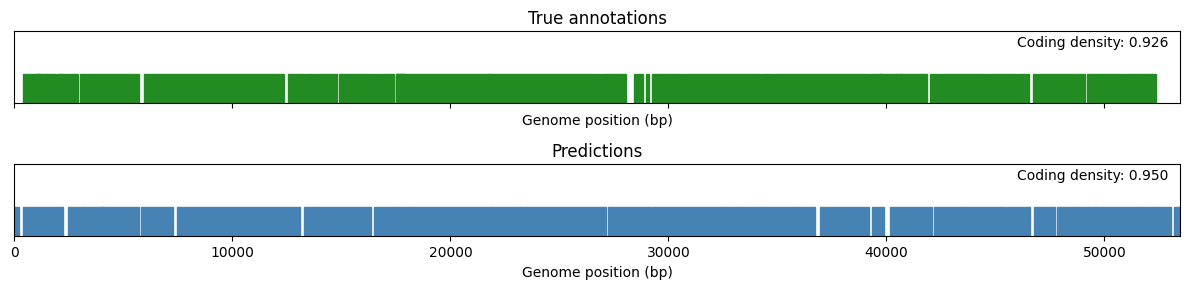

In [143]:
fig = compare_coding_regions(nc_true, nc_xgb, nc_len) 

## Next steps

- Try different feature sets or add engineered features in `src/ml_features.rs`.
- Experiment with class weights, regularisation, or alternative models.
- For non-linear models (XGBoost), export to ONNX with `onnxmltools`.
- Use the exported ONNX model with PHANOTATE-rs:
  ```bash
  ./target/release/phanotate-rs -i genome.fasta --model outputs/model_final.onnx -f sco
  ```